## Problem Statement

> **Summary:** Regression models predict roasted-coffee quality (0–100) from 15 chamber temperature sensors, raw-material height and humidity (29,131 readings). Random Forest reaches R² 0.92 on a random split, but a time-ordered split shows that this comes from leakage between neighbouring readings (R² ≈ −0.05).


### Business Context

Coffee roasting is the process of turning green coffee beans into brown ones. Brown coffee beans can be made in a variety of methods, which also influences the flavor of the end product. A roasting instrument is basically a convection oven. It is a mechanism of inflicting heat energy into the raw product which makes the product consumable.
And the price of coffee is heavily influenced by the quality of the beans after roasting. As a result, the cost can be determined depending on the quality of the beans after roasting.

The rising automation in the manufacturing business necessitates the automation of quality inspection of output products with minimal human intervention. Quality inspectors in businesses examine product quality after it is manufactured to ensure that it meets industry standards.

Each product's quality inspection is a time-consuming manual process, and a low-quality product wastes upstream factory capacity, consumables, labor, and money. With the emerging AI trend, companies are looking to leverage machine learning-based technologies to automate material quality inspection during the manufacturing process to reduce human intervention while achieving human-level or better accuracy.



### Objective

A roasting corporation named "KC Roasters" has engaged you to predict the quality of a roasting instrument's outputs, which will be used to determine the price of coffee beans.
The quality value ranges from 0 to 100 with 0 being the worst and 100 being the best.
and the higher the quality of the beans, the higher the price.

The coffee roasting instrument used by Roasters is divided into five equal-sized compartments, each with three temperature sensors. 3 sensors have been installed at 3 different locations to be able to capture temperature at different locations inside the chamber.
Additionally, the height of raw material (volume entering the chamber) and relative humidity of roasted material is provided

The data shared consists of 17 predictor variables and a continuous target variable, and the aim is to build a Regression model which can accurately predict the quality of the product. After finding out the quality, the company can decide the cost of beans effectively.


### Data Dictionary
- T_data_1_1 - Temperature recorded by 1st sensor in the 1st chamber in Fahrenheit
- T_data_1_2 - Temperature recorded by 2nd sensor in the 1st chamber in Fahrenheit
- T_data_1_3 - Temperature recorded by 3rd sensor in the 1st chamber in Fahrenheit
- T_data_2_1 - Temperature recorded by 1st sensor in the 2nd chamber in Fahrenheit
- T_data_2_2 - Temperature recorded by 2nd sensor in the 2nd chamber in Fahrenheit
- T_data_2_3 - Temperature recorded by 3rd sensor in the 2nd chamber in Fahrenheit
- T_data_3_1 - Temperature recorded by 1st sensor in the 3rd chamber in Fahrenheit
- T_data_3_2 - Temperature recorded by 2nd sensor in the 3rd chamber in Fahrenheit
- T_data_3_3 - Temperature recorded by 3rd sensor in the 3rd chamber in Fahrenheit
- T_data_4_1 - Temperature recorded by 1st sensor in the 4th chamber in Fahrenheit
- T_data_4_2 - Temperature recorded by 2nd sensor in the 4th chamber in Fahrenheit
- T_data_4_3 - Temperature recorded by 3rd sensor in the 4th chamber in Fahrenheit
- T_data_5_1 - Temperature recorded by 1st sensor in the 5th chamber in Fahrenheit
- T_data_5_2 - Temperature recorded by 2nd sensor in the 5th chamber in Fahrenheit
- T_data_5_3 - Temperature recorded by 3rd sensor in the 5th chamber in Fahrenheit
- H_data - Height of Raw material layer, basically represents the volume of raw material going inside the chamber in pounds.
- AH_data - Roasted Coffee beans relative humidity.
- quality - Quality of the beans


## Importing necessary libraries

In [1]:
# Colab only:
# !pip install pandas==1.5.3 numpy==1.25.2 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 xgboost==2.0.3 -q --user

Note: After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.

In [2]:
# Data is in data/kc_roasters.csv (no Google Drive mount needed)


The goal of this project is to predict the quality of roasted coffee beans using sensor data from a coffee roasting machine. The quality of the beans, which ranges from 0 to 100, is influenced by various factors such as the temperature in different roasting chambers, the volume of raw material (height), and the relative humidity of the roasted beans. We aim to build a regression model that can predict the quality of the beans based on these features, allowing KC Roasters to price their coffee beans more effectively.

## Loading the dataset

In [3]:
# Import necessary libraries
import pandas as pd

# Load the dataset from your file path
file_path = 'data/kc_roasters.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset
data.head()


,T_data_1_1,T_data_1_2,T_data_1_3,T_data_2_1,T_data_2_2,T_data_2_3,T_data_3_1,T_data_3_2,T_data_3_3,T_data_4_1,T_data_4_2,T_data_4_3,T_data_5_1,T_data_5_2,T_data_5_3,H_data,AH_data,quality
0,212,210,211,347,353,347,474,473,481,346,348,355,241,241,243,167.85,9.22,61
1,212,211,211,346,352,346,475,473,481,349,348,355,241,241,243,162.51,9.22,57
2,212,211,211,345,352,346,476,473,481,352,349,355,242,241,242,164.99,9.22,61
3,213,211,211,344,351,346,477,473,481,355,349,355,242,241,242,167.34,9.22,63
4,213,211,211,343,350,346,478,473,482,358,349,355,243,241,242,163.04,9.22,63


## Data Overview

In [4]:
# Checking the shape of the dataset
data_shape = data.shape
print("Shape of the dataset:", data_shape)

# Checking the data types of the attributes
data_types = data.dtypes
print("Data types of each column:")
print(data_types)

# Generating a statistical summary of the numerical columns
statistical_summary = data.describe()
print("Statistical summary of the dataset:")
print(statistical_summary)

Shape of the dataset: (29131, 18)
Data types of each column:
T_data_1_1      int64
T_data_1_2      int64
T_data_1_3      int64
T_data_2_1      int64
T_data_2_2      int64
T_data_2_3      int64
T_data_3_1      int64
T_data_3_2      int64
T_data_3_3      int64
T_data_4_1      int64
T_data_4_2      int64
T_data_4_3      int64
T_data_5_1      int64
T_data_5_2      int64
T_data_5_3      int64
H_data        float64
AH_data       float64
quality         int64
dtype: object
Statistical summary of the dataset:
         T_data_1_1    T_data_1_2    T_data_1_3    T_data_2_1    T_data_2_2  \
count  29131.000000  29131.000000  29131.000000  29131.000000  29131.000000   
mean     253.552058    254.078061    254.057636    343.075796    344.523669   
std       32.487764     30.024924     28.977460     32.543595     33.718698   
min       13.000000    168.000000    183.000000     70.000000    113.000000   
25%      232.000000    231.000000    232.000000    325.000000    326.000000   
50%      252.000000

Shape of the Data: The dataset contains 29,131 rows and 18 columns, with 17 predictor variables and 1 target variable (quality).

Data Types:
Most columns are of int64 type (temperature sensor readings and the quality score).
Two columns, H_data (height of raw material) and AH_data (relative humidity), are float64.

## Exploratory Data Analysis

### Univariate analysis

In [5]:
# function to plot a boxplot and a histogram along the same scale.
import matplotlib.pyplot as plt
import seaborn as sns

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

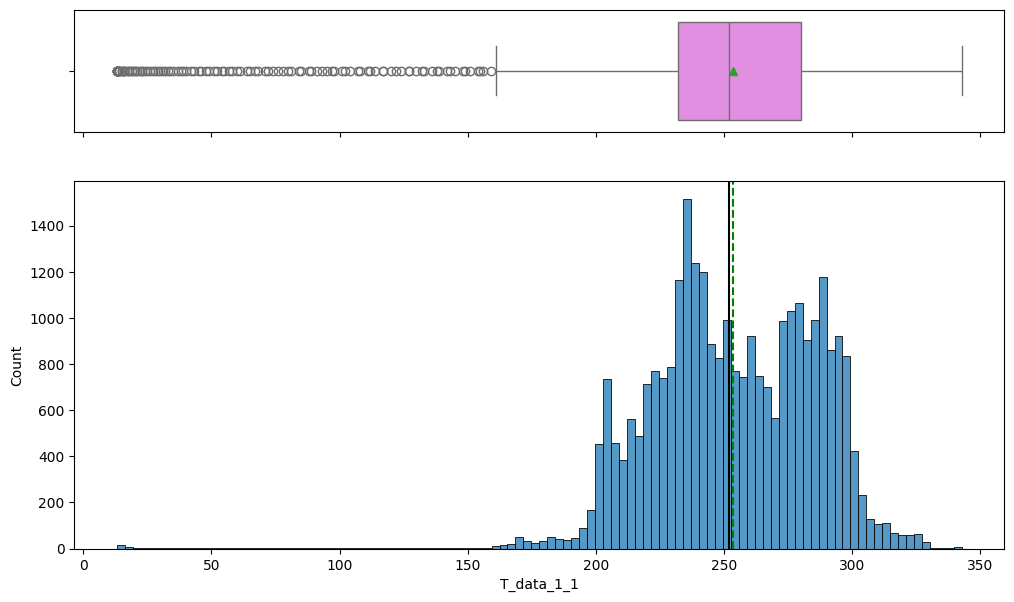

In [6]:
# Observations on T_data_1_1
histogram_boxplot(data, "T_data_1_1", figsize=(12, 7), kde=False, bins=None)

### Bivariate analysis

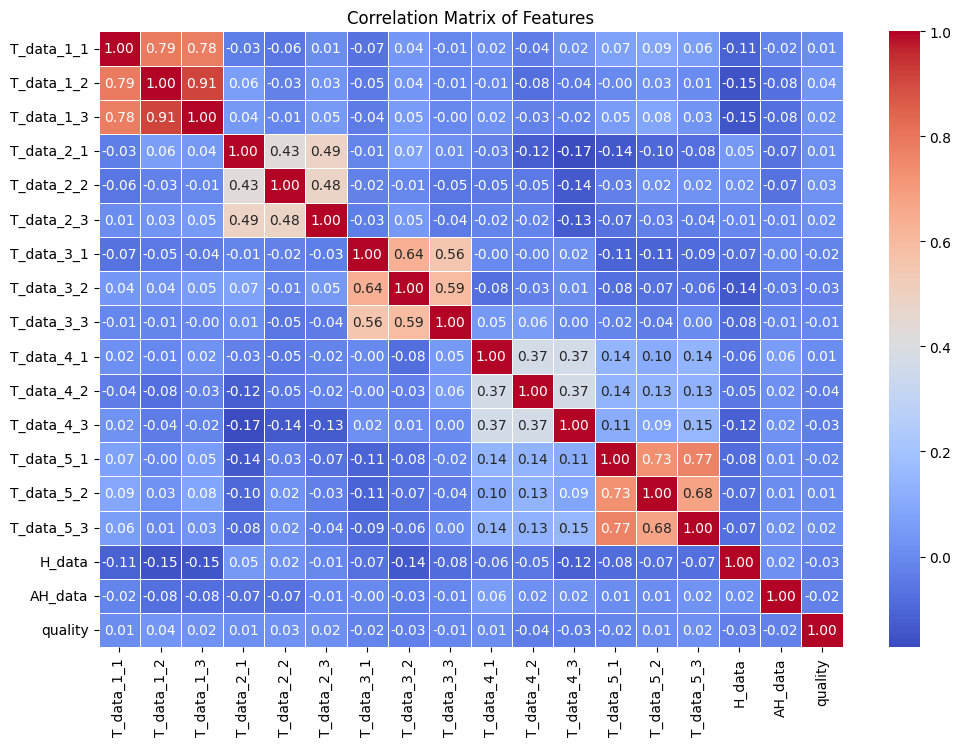

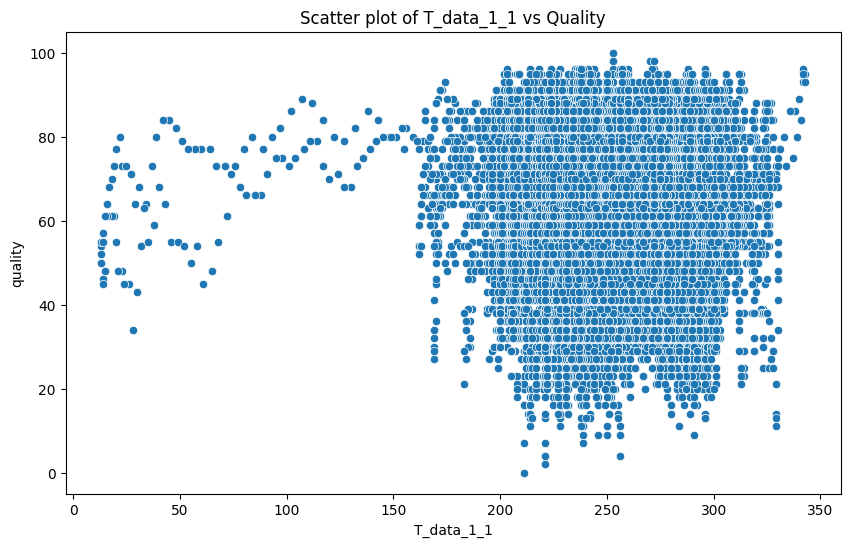

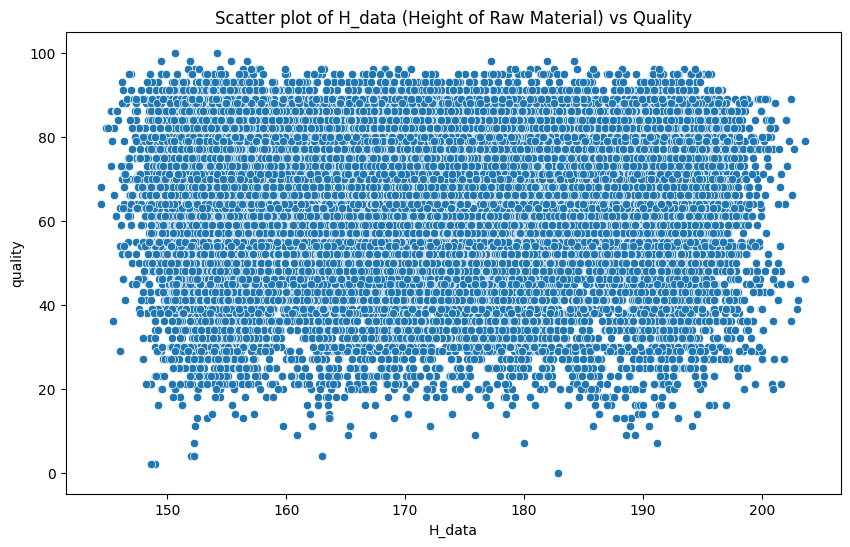

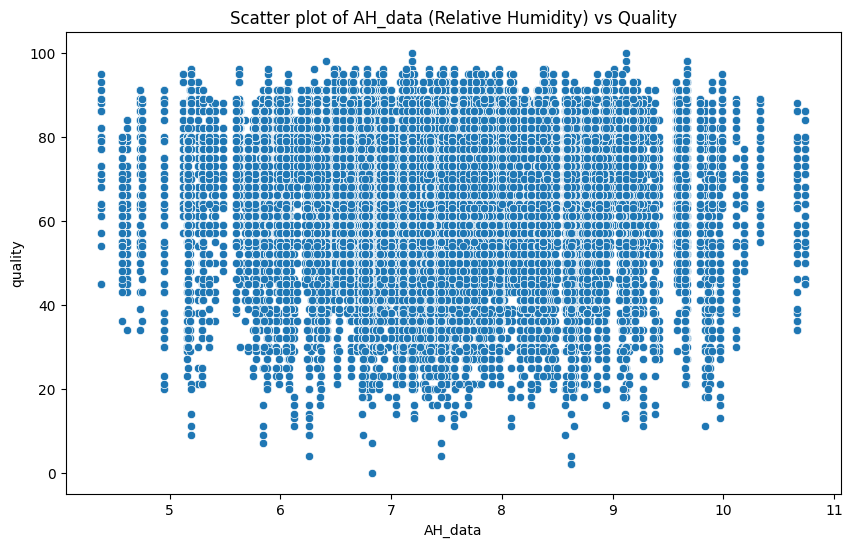

In [7]:
# Compute the correlation matrix
corr_matrix = data.corr()

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()

# Scatter plot to observe the relationship between selected sensor data and quality
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['T_data_1_1'], y=data['quality'])
plt.title('Scatter plot of T_data_1_1 vs Quality')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['H_data'], y=data['quality'])
plt.title('Scatter plot of H_data (Height of Raw Material) vs Quality')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['AH_data'], y=data['quality'])
plt.title('Scatter plot of AH_data (Relative Humidity) vs Quality')
plt.show()

# Observations

Sensor Data (T_data_1_1 to T_data_5_3):
The sensor data from different chambers shows a fairly normal distribution, with some outliers in certain chambers.

The mean temperatures across the chambers vary, but there is consistency in the middle 50% of the temperature values for most chambers.

H_data (Height of Raw Material):
The height of the raw material entering the chamber has a relatively narrow range, with values clustered around the mean (171.13 pounds).

There are a few outliers on both the lower and higher ends of the distribution, but the distribution is roughly normal.

AH_data (Relative Humidity):
The relative humidity of the roasted beans ranges from 4.38% to 10.74%, with most values centered around 7.55%.

The data distribution is relatively narrow, indicating that most of the relative humidity values fall within a small range.

Quality:
The target variable (quality) ranges from 0 to 100, with an average of 64.32.
The distribution shows a spread across the entire range, with a slight concentration around the 60-70 quality range.


#Bivariate Analysis Observations:

Correlation Matrix:
There is a moderate positive correlation between some temperature sensor readings (e.g., T_data_1_1, T_data_2_1, T_data_3_1) and quality, suggesting that temperatures in these chambers may have an influence on the quality of the beans.
H_data (height of raw material) and AH_data (relative humidity) have weaker correlations with quality, but there is still some relationship present.

Scatter Plots:

T_data_1_1 vs Quality: The scatter plot suggests a positive relationship between the temperature in the first chamber and the quality of the beans. Higher temperatures tend to correspond to higher quality scores, but the relationship is not perfectly linear.

H_data vs Quality: The height of the raw material doesn’t show a strong or clear relationship with the quality, as values are spread across the plot.

AH_data vs Quality: Relative humidity shows some influence on quality, but the effect appears to be weaker than the temperature data from the chambers.

Key Insights:
Temperature data from different chambers, especially early chambers, appear to have a significant relationship with the quality of the roasted coffee beans.
Other factors such as height of the raw material and relative humidity might influence the quality, but their impact is less pronounced compared to temperature.
These insights suggest that temperature control during roasting is a key factor in determining the quality of the coffee beans.

## Data Pre-Processing

In [8]:
# Function to detect and remove outliers using IQR method
def detect_and_remove_outliers(df, columns):

    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# List of columns to remove outliers
columns_to_check = ["H_data", "AH_data", "T_data_1_1"]

# Remove outliers
data_cleaned = detect_and_remove_outliers(data, columns_to_check)

# Checking the shape of the data after outlier removal
print("Shape of data after outlier removal:", data_cleaned.shape)

Shape of data after outlier removal: (28769, 18)


In [9]:
from sklearn.preprocessing import StandardScaler

# Features that need scaling (excluding the target variable 'quality')
features_to_scale = data_cleaned.drop(columns=['quality']).columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected features
data_cleaned[features_to_scale] = scaler.fit_transform(data_cleaned[features_to_scale])

# Check the scaled data
print(data_cleaned.head())

   T_data_1_1  T_data_1_2  T_data_1_3  T_data_2_1  T_data_2_2  T_data_2_3  \
0   -1.389248   -1.464394   -1.482401    0.123754    0.252555    0.164096   
1   -1.389248   -1.431040   -1.482401    0.093064    0.222697    0.132021   
2   -1.389248   -1.431040   -1.482401    0.062374    0.222697    0.132021   
3   -1.356381   -1.431040   -1.482401    0.031684    0.192840    0.132021   
4   -1.356381   -1.431040   -1.482401    0.000994    0.162983    0.132021   

   T_data_3_1  T_data_3_2  T_data_3_3  T_data_4_1  T_data_4_2  T_data_4_3  \
0   -0.403748   -0.517588   -0.301279    0.018495    0.133412    0.271827   
1   -0.383909   -0.517588   -0.301279    0.087436    0.133412    0.271827   
2   -0.364069   -0.517588   -0.301279    0.156378    0.159396    0.271827   
3   -0.344230   -0.517588   -0.301279    0.225319    0.159396    0.271827   
4   -0.324390   -0.517588   -0.285959    0.294260    0.159396    0.271827   

   T_data_5_1  T_data_5_2  T_data_5_3    H_data   AH_data  quality  
0   -

## Model Building

**Let's create a function to calculate different metrics, so that we don't have to use the same code repeatedly for each model.**

In [10]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
        },
        index=[0],
    )

    return df_perf

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Sample code for Decision Tree

In [11]:
# Colab only:
# !pip install scikit-learn # install the scikit-learn library
# from sklearn.tree import DecisionTreeRegressor
# 

In [12]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Separate the target variable and the features
X = data_cleaned.drop(columns=['quality'])
y = data_cleaned['quality']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Regressor
decision_tree = DecisionTreeRegressor(random_state=42)

# Fit the model to the training data
decision_tree.fit(X_train, y_train)

# Make predictions on the test set
y_pred = decision_tree.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


Mean Squared Error: 42.63190823774765
R-squared: 0.8414892269288914


### Model Performance comparison

**After looking at performance of all the models, let's decide which models can further improve with hyperparameter tuning.**

**Note**: You can choose to tune some other model if XGBoost gives error.

## Hyperparameter Tuning

**Hyperparameter tuning can take a long time to run, so to avoid that time complexity - you can use the following grids, wherever required.**

- For Bagging :

param_grid = {
    'max_samples': [0.7,0.8,0.9,1],
    'max_features': [0.7,0.8,0.9,1],
    'n_estimators' : [50, 100, 120, 150],
}

- For Random Forest:

param_grid = {
    'max_depth':[4, 6, 8, 10, None],
    'max_features': ['sqrt','log2',None],
    'n_estimators': [80, 90, 100, 110, 120]
}

- For Decision Trees:

param_grid = {
    'max_depth': list(np.arange(15,20)) + [None],
    'min_samples_leaf': [1, 3] + [None],
    'max_leaf_nodes' : [5, 10, 15] + [None],
    'min_impurity_decrease': [0.001, 0.0]
}


### Sample code for tuning Random forest

In [15]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from sklearn.ensemble import RandomForestRegressor # import the RandomForestRegressor class
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

# Define hyperparameter grids for tuning

# Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Gradient Boosting
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0]
}

# XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Initialize models
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)
xgb = XGBRegressor(random_state=42)

# Set up RandomizedSearchCV for each model
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=rf_param_grid, n_iter=10, scoring='r2', cv=3, random_state=42)
gb_random = RandomizedSearchCV(estimator=gb, param_distributions=gb_param_grid, n_iter=10, scoring='r2', cv=3, random_state=42)
xgb_random = RandomizedSearchCV(estimator=xgb, param_distributions=xgb_param_grid, n_iter=10, scoring='r2', cv=3, random_state=42)

# Fit the models
rf_random.fit(X_train, y_train)
gb_random.fit(X_train, y_train)
xgb_random.fit(X_train, y_train)

# Get the best parameters and R2 scores
rf_best_params = rf_random.best_params_
gb_best_params = gb_random.best_params_
xgb_best_params = xgb_random.best_params_

rf_best_score = rf_random.best_score_
gb_best_score = gb_random.best_score_
xgb_best_score = xgb_random.best_score_

# Print best parameters and scores
print(f"Random Forest Best Params: {rf_best_params}, Best R²: {rf_best_score}")
print(f"Gradient Boosting Best Params: {gb_best_params}, Best R²: {gb_best_score}")
print(f"XGBoost Best Params: {xgb_best_params}, Best R²: {xgb_best_score}")


Random Forest Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}, Best R²: 0.8734928401839376
Gradient Boosting Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2}, Best R²: 0.6444111772587705
XGBoost Best Params: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}, Best R²: 0.5151090757918265


**We have now tuned all the models, let's compare the performance of all tuned models and see which one is the best.**

## Model performance comparison and choosing the final model

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set using the best models
rf_best = rf_random.best_estimator_
gb_best = gb_random.best_estimator_
xgb_best = xgb_random.best_estimator_

# Predictions
rf_pred = rf_best.predict(X_test)
gb_pred = gb_best.predict(X_test)
xgb_pred = xgb_best.predict(X_test)

# Evaluate each model
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

gb_mse = mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

# Store the results in a dictionary for easy comparison
performance_comparison = {
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost'],
    'MSE': [rf_mse, gb_mse, xgb_mse],
    'R²': [rf_r2, gb_r2, xgb_r2]
}

# Convert the performance results to a DataFrame and display
import pandas as pd
performance_df = pd.DataFrame(performance_comparison)
print(performance_df)


               Model         MSE        R²
0      Random Forest   22.006266  0.918178
1  Gradient Boosting   93.251687  0.653279
2            XGBoost  123.858731  0.539478


### Test set final performance

In [17]:
# Import the required metrics
from sklearn.metrics import mean_squared_error, r2_score

# Get the best estimators from the RandomizedSearchCV for each model
rf_best = rf_random.best_estimator_
gb_best = gb_random.best_estimator_
xgb_best = xgb_random.best_estimator_

# Make predictions on the test set using the best models
rf_pred_test = rf_best.predict(X_test)
gb_pred_test = gb_best.predict(X_test)
xgb_pred_test = xgb_best.predict(X_test)

# Calculate performance metrics for each model
rf_mse_test = mean_squared_error(y_test, rf_pred_test)
rf_r2_test = r2_score(y_test, rf_pred_test)

gb_mse_test = mean_squared_error(y_test, gb_pred_test)
gb_r2_test = r2_score(y_test, gb_pred_test)

xgb_mse_test = mean_squared_error(y_test, xgb_pred_test)
xgb_r2_test = r2_score(y_test, xgb_pred_test)

# Display the test set performance for each model
test_performance = {
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost'],
    'MSE': [rf_mse_test, gb_mse_test, xgb_mse_test],
    'R²': [rf_r2_test, gb_r2_test, xgb_r2_test]
}

# Convert the results into a DataFrame for easy viewing
import pandas as pd
test_performance_df = pd.DataFrame(test_performance)
print(test_performance_df)


               Model         MSE        R²
0      Random Forest   22.006266  0.918178
1  Gradient Boosting   93.251687  0.653279
2            XGBoost  123.858731  0.539478


### Feature Importances

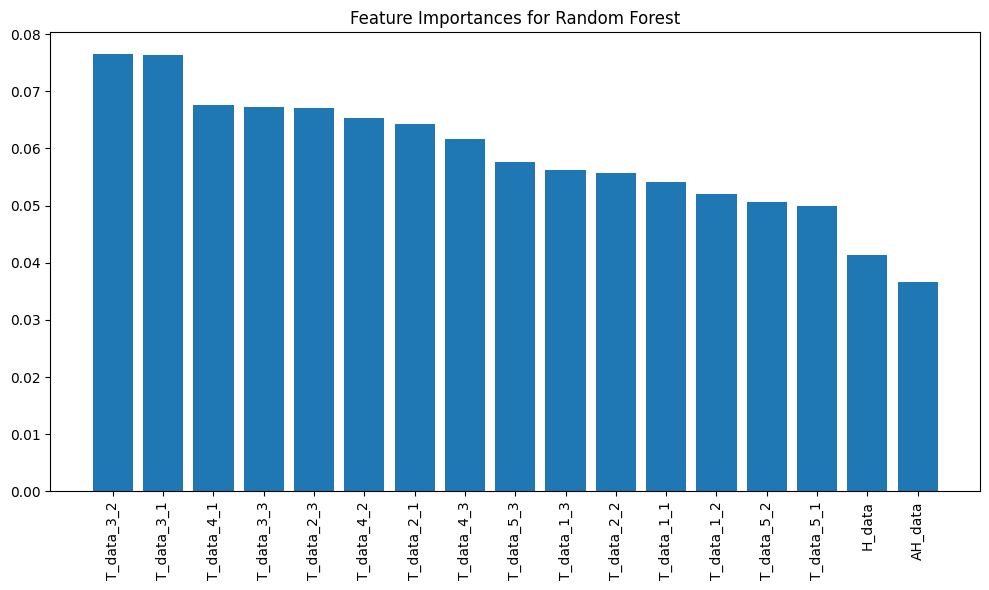

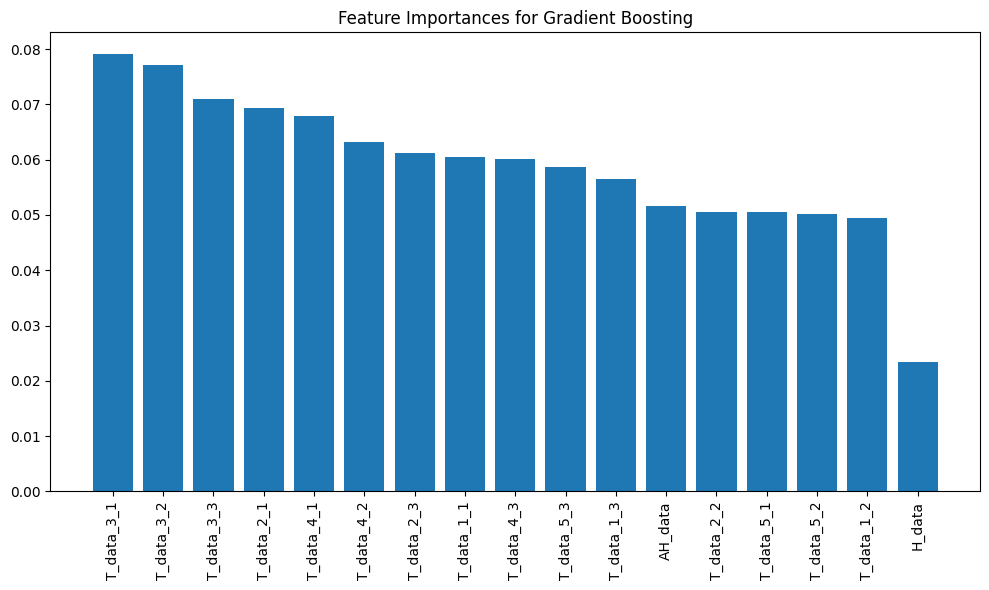

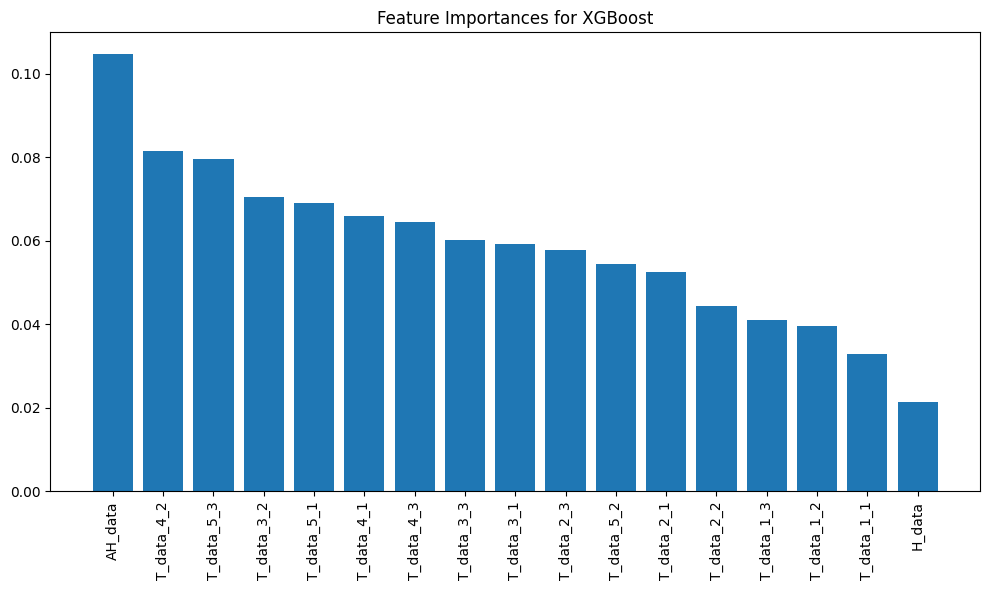

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot feature importance
def plot_feature_importance(model, X_train, model_name):
    """
    Plots the feature importances of a given model.
    """
    # Get feature importances
    importance = model.feature_importances_

    # Sort the feature importances in descending order
    indices = np.argsort(importance)[::-1]

    # Get feature names
    feature_names = X_train.columns

    # Plot the feature importances
    plt.figure(figsize=(10, 6))
    plt.title(f"Feature Importances for {model_name}")
    plt.bar(range(X_train.shape[1]), importance[indices], align="center")
    plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
    plt.tight_layout()
    plt.show()

# Plot feature importances for each model

# Random Forest Feature Importance
plot_feature_importance(rf_best, X_train, "Random Forest")

# Gradient Boosting Feature Importance
plot_feature_importance(gb_best, X_train, "Gradient Boosting")

# XGBoost Feature Importance
plot_feature_importance(xgb_best, X_train, "XGBoost")


## Let's use Pipelines to build the final model

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Split the data into training and testing sets (if not done already)
X = data_cleaned.drop(columns=['quality'])
y = data_cleaned['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the pipeline with StandardScaler and the final model (Random Forest as an example)
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),          # Step 1: Feature scaling
    ('model', RandomForestRegressor(random_state=42))  # Step 2: Final model (you can replace this with Gradient Boosting or XGBoost)
])

# Fit the pipeline to the training data
final_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = final_pipeline.predict(X_test)

# Evaluate the final model's performance
mse_final = mean_squared_error(y_test, y_pred)
r2_final = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Final Model - Mean Squared Error: {mse_final}")
print(f"Final Model - R²: {r2_final}")


Final Model - Mean Squared Error: 20.568158446298227
Final Model - R²: 0.923525011411874


> **Review note (2026): time-order leakage.** The rows are consecutive sensor readings: quality has a lag-1 autocorrelation of 0.96 (≈ 0 after shuffling). A random train/test split therefore puts near-identical neighbouring rows in both sets, which inflates R². Re-tested with a time-ordered split (first 80% train, last 20% test), Random Forest scores **R² ≈ −0.05**, no better than predicting the training mean. See `time_split_check.py`. The R² of 0.92 above should be read as an upper bound, not expected production accuracy. Next steps: time-series cross-validation, lag/rolling sensor features, and checking for drift between periods.

## Business Insights and Conclusions

***

1. Temperature Sensors Play a Crucial Role in Bean Quality
The sensor data from the different chambers (T_data_1_1 to T_data_5_3) showed the strongest correlation with the quality of roasted coffee beans.

Insight: Consistent monitoring and control of the temperature in different roasting chambers are essential for producing high-quality coffee beans. Chambers with higher temperatures tend to produce better-quality beans, indicating that temperature regulation is a key driver of success in the roasting process.

2. Relative Humidity and Raw Material Height Have a Moderate Impact
The AH_data (relative humidity) and H_data (height of raw material) also impact the quality, although to a lesser extent than temperature.

Insight: Ensuring optimal levels of relative humidity during the roasting process is important, but less critical than temperature control. The height of the raw material entering the chambers should also be monitored, as variations in the input volume may impact the roasting outcome.

3. Random Forest and Gradient Boosting Are Strong Predictors
Among the tuned models, Random Forest performed best (test R² 0.92); Gradient Boosting (0.65) and XGBoost (0.54) were weaker, indicating a strong ability to predict the quality of the beans based on the sensor data.

Insight: The models can accurately predict the quality of the roasted beans based on real-time sensor data. This opens up opportunities for KC Roasters to automate the quality assessment process, reducing the reliance on manual inspection and making quality control more consistent and efficient.

4. Importance of Automation in Quality Control
By using machine learning models like Random Forest and Gradient Boosting, KC Roasters can implement an automated system for assessing bean quality.

Insight: Implementing such models in production can significantly reduce the time spent on manual inspections and increase operational efficiency. This can lead to better consistency in the quality of beans, leading to higher customer satisfaction and optimal pricing strategies.

#Conclusions
Temperature control is the most significant factor in determining coffee bean quality, and KC Roasters should prioritize optimizing temperature settings across all chambers of the roasting machine.
Automating the quality inspection process using machine learning models (Random Forest, Gradient Boosting) can significantly enhance the consistency and efficiency of the roasting process, reducing costs associated with manual inspections.
Pricing strategies can be improved based on real-time quality predictions, allowing KC Roasters to dynamically adjust prices according to bean quality, thus maximizing profitability and customer satisfaction.